In [ ]:
#CIS 331 Final Project, Tony Viravouth

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading the csv file
from google.colab import files
data = files.upload()

Saving water_potability.csv to water_potability.csv


In [ ]:
#creating a dataframe with the csv file
data = pd.read_csv('water_potability.csv')

In [ ]:
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
#identifying possible nulll features to clean up the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
#we are counting the amount of null values in the 3 attributes
data.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:
data.Potability.value_counts()

,count
Potability,
0,1998
1,1278


In [ ]:
#we are dropping the null values from the data
data = data.dropna()

In [ ]:
#number of adjusted samples with null values taken out
data.Potability.value_counts()

,count
Potability,
0,1200
1,811


In [ ]:
#to prevent bias we resample the data using resample and shuffle
#https://scikit-learn.org/1.5/modules/generated/sklearn.utils.resample.html
#https://scikit-learn.org/1.5/modules/generated/sklearn.utils.shuffle.html
notpotable  = data[data['Potability']==0]
potable = data[data['Potability']==1]

from sklearn.utils import resample
df_minority_upsampled = resample(potable, replace = True, n_samples = 1200)

from sklearn.utils import shuffle
data = pd.concat([notpotable, df_minority_upsampled])
data = shuffle(data)

In [ ]:
data.shape

(2400, 10)

In [ ]:
data.Potability.value_counts()

,count
Potability,
0,1200
1,1200


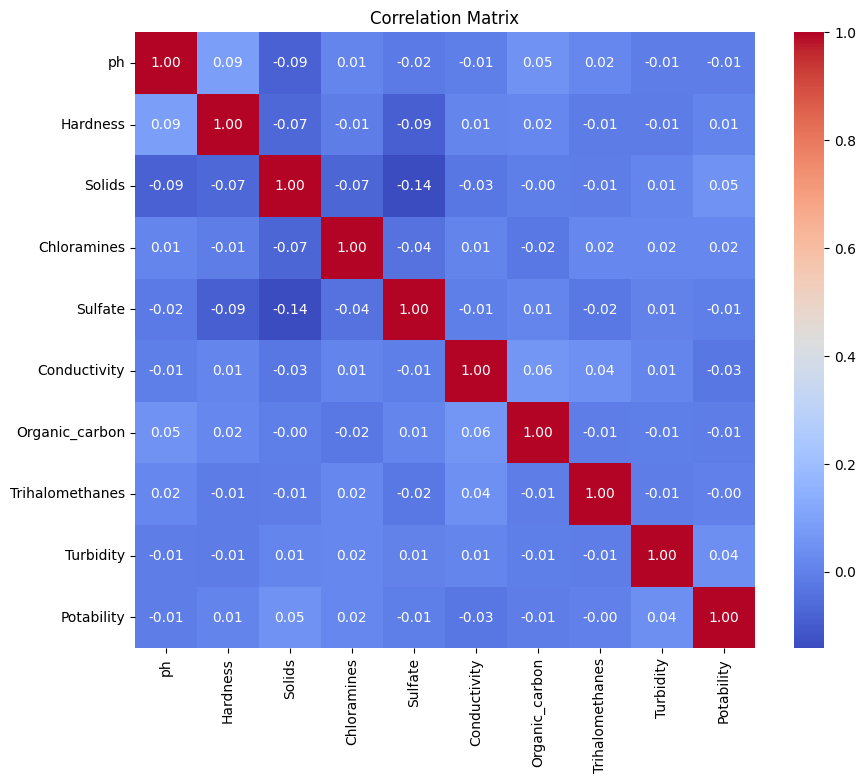

In [ ]:
#creating a heatmap to show correlations between features that can help suggest direct releations between them.
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

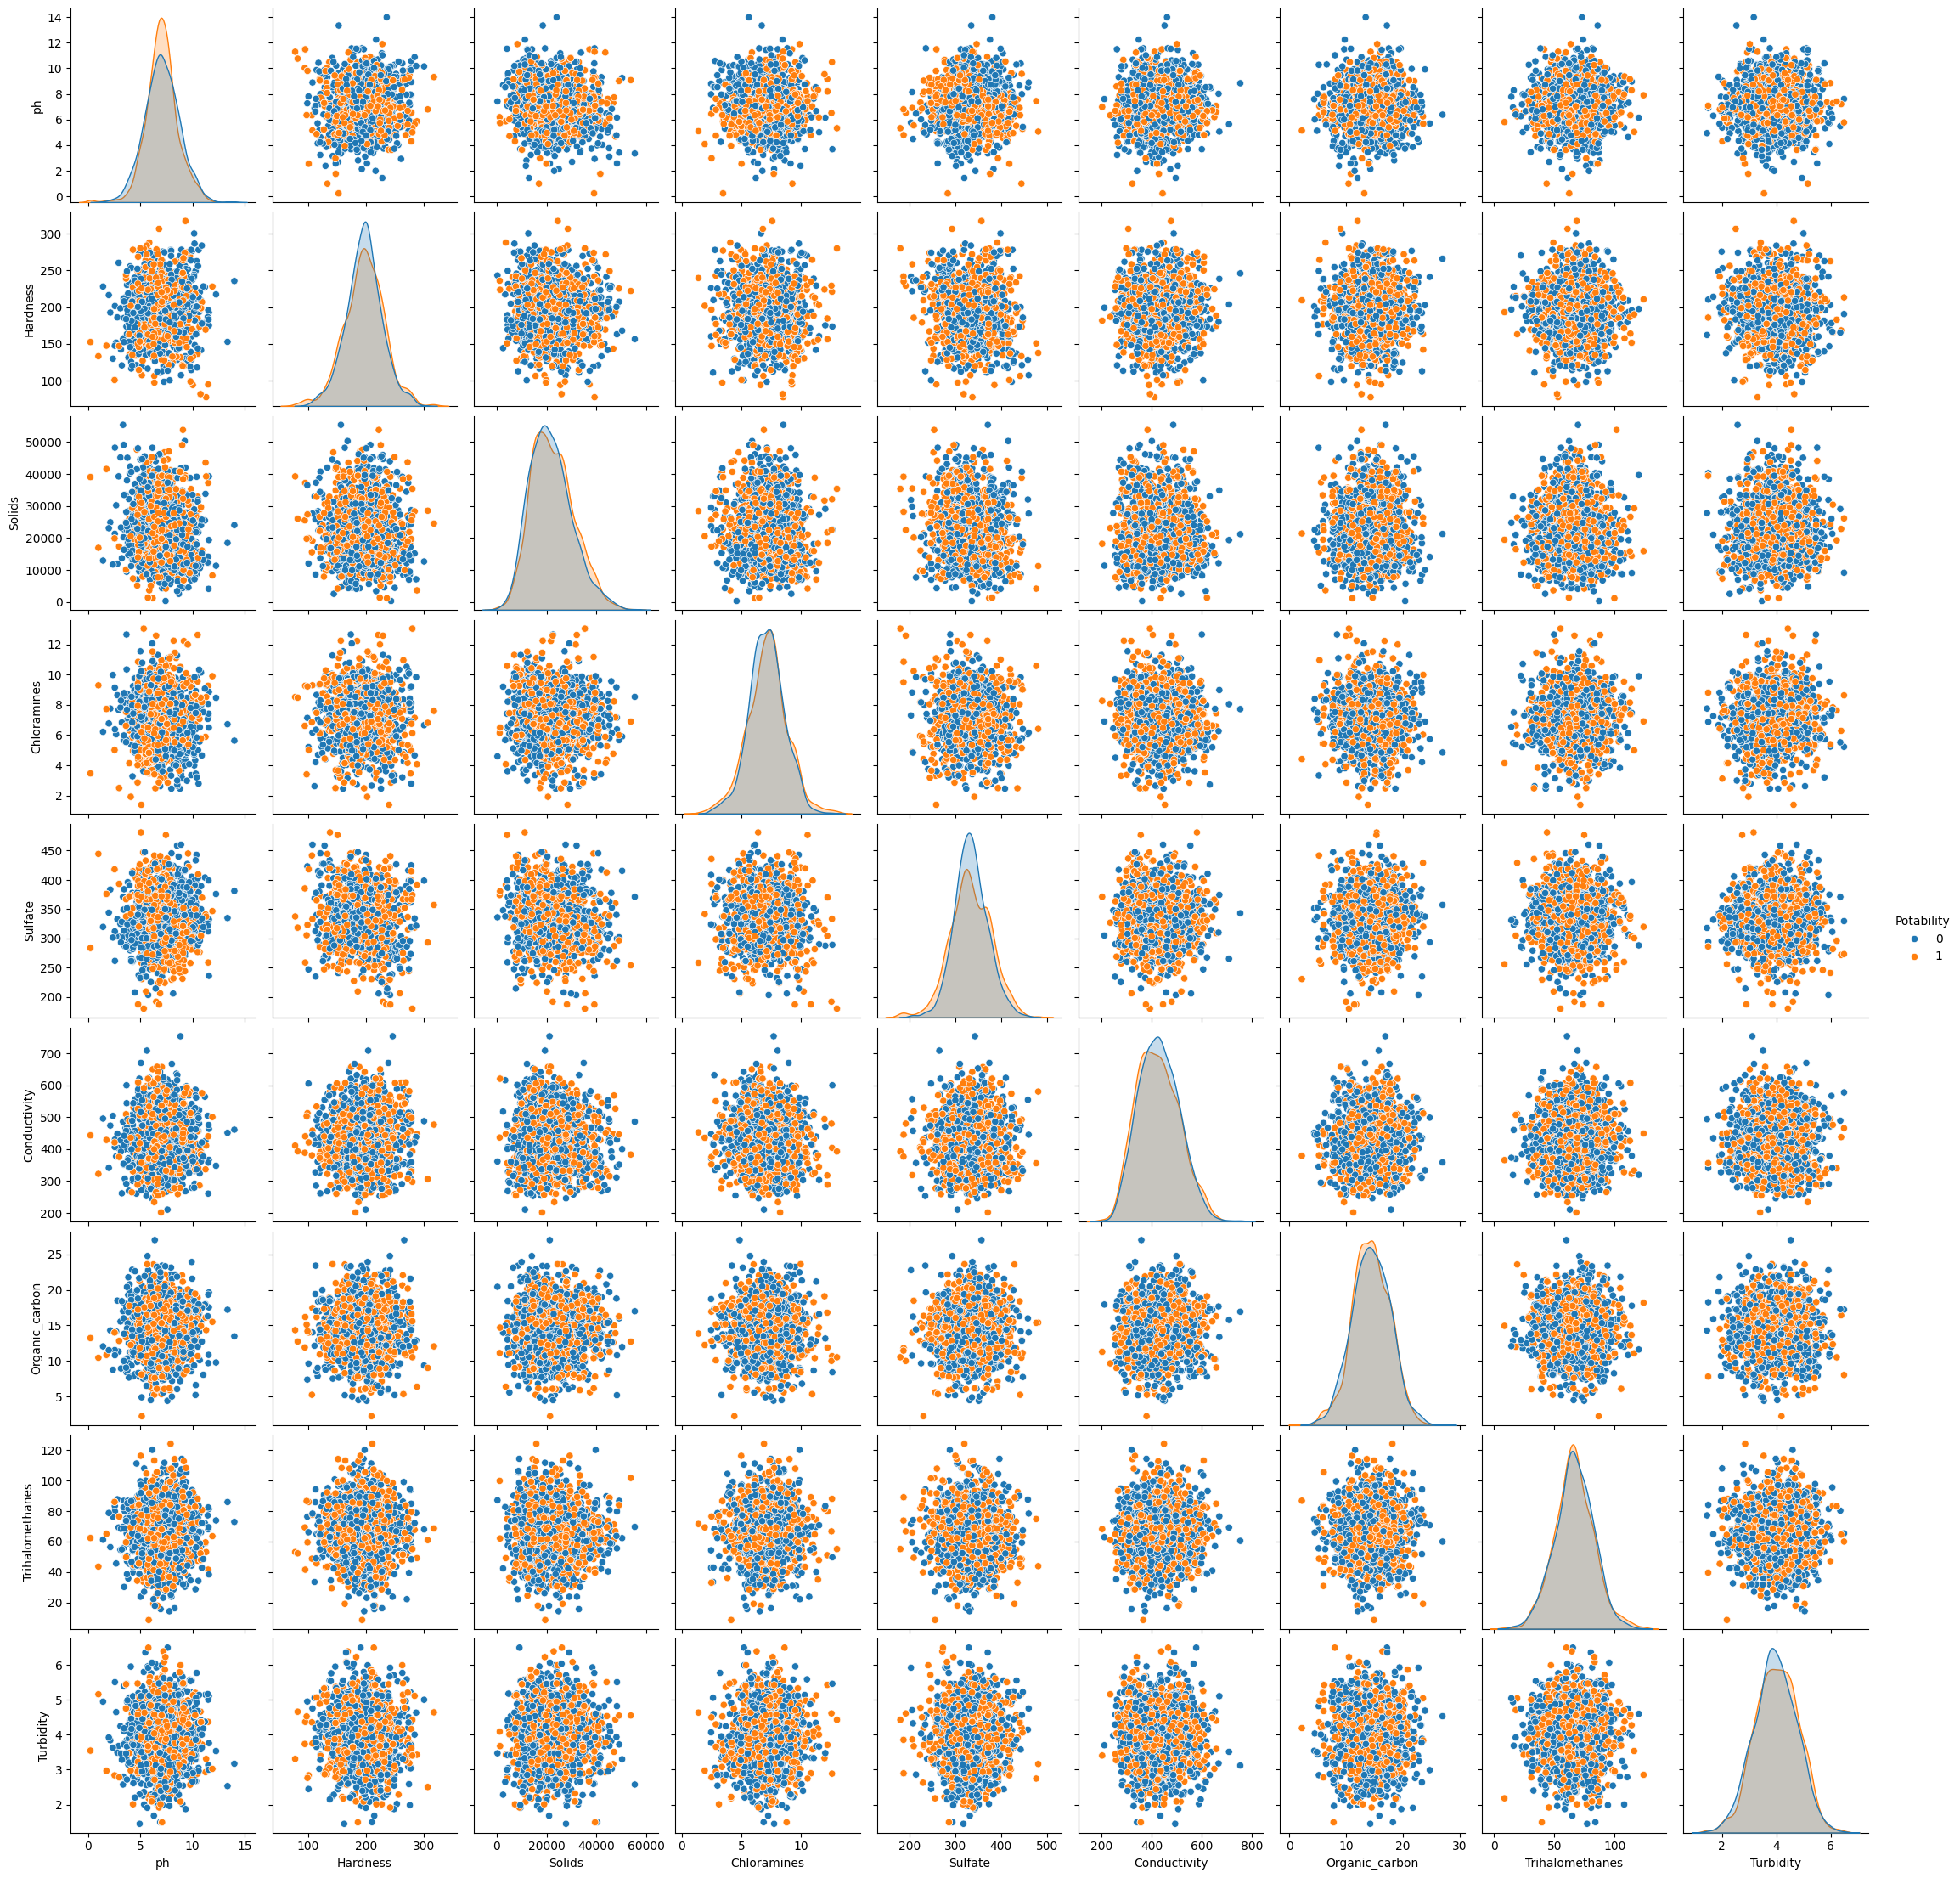

In [ ]:
sns.pairplot(data, hue="Potability", diag_kind="kde")
plt.show()

In [ ]:
#We start to build the model
#first we split the data
from sklearn.model_selection import train_test_split


X = data.drop("Potability", axis=1)
y = data["Potability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#next we train the classification model
#we decide to use random forest here
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Accuracy: 0.8291666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       240
           1       0.84      0.82      0.83       240

    accuracy                           0.83       480
   macro avg       0.83      0.83      0.83       480
weighted avg       0.83      0.83      0.83       480



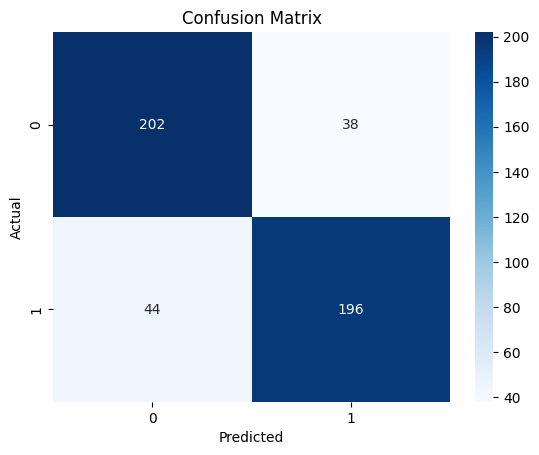

In [ ]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

#we figure the accuracy of the model and use a confusion matrix tool to help
#visualize the accuracy of our model labels to the actual data set labels
#https://scikit-learn.org/dev/modules/generated/sklearn.metrics.confusion_matrix.html
#https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.classification_report.html
print("Accuracy:", accuracy_score(y_test, y_pred))

#we also use a classifacation report to show precision, recall, f1-score, and support
print("\nClassification Report:\n", classification_report(y_test, y_pred))


conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()